<a href="https://colab.research.google.com/github/chiyeon01/Retouch_Your_Photo/blob/main/model_train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 주요 라이브러리 다운로드

In [ ]:
!pip -q install torchinfo
!pip -q install ultralytics
!pip install torchinfo
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 64.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 58.4 MB/s eta 0:00:00


# Module Import

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchinfo
from torchinfo import summary
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from torch.optim import Adam
import torchmetrics

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
import cv2
import os
import albumentations as A

from albumentations.pytorch import ToTensorV2
from tqdm import tqdm
from PIL import Image

from ultralytics import YOLO
from transformers import pipeline

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# Google Drive 접근

In [ ]:
from google.colab import drive

drive.mount("/content/gdrive")

Mounted at /content/gdrive


In [ ]:
!unzip -q "/content/gdrive/MyDrive/Colab Notebooks/z.대회 & 프로젝트/2026_ALOM DEMO/Dataset.zip"

# 모델 학습

In [ ]:
# CNN 학습 Class
class Trainer:
    def __init__(self, model=None, train_dataloader=None, val_dataloader=None, loss_fn=None, optimizer=None):
        self.model = model
        self.val_dataloader = val_dataloader
        self.loss_fn = loss_fn
        self.optimizer = optimizer

    # 1번 에포크 학습 함수
    def train_epoch(self, epoch, train_dataloader):
        device = torch.device('cuda:0' if torch.cuda.is_available else 'cpu')

        self.model = self.model.to(device)

        # 평균 loss를 구하기 위한 변수
        avg_loss = 0
        sum_loss = 0

        # 모델 학습 설정
        self.model.train()

        with tqdm(total = len(train_dataloader), desc=f"[Training...] / EPOCH: {epoch} ", leave=True) as progress_bar:
            for batch_idx, (images, depth_maps, masks, styleIds, labels) in enumerate(train_dataloader):
                images = images.to(device)
                depth_maps = depth_maps.to(device)
                masks = masks.to(device)
                styleIds = styleIds.to(device)
                labels = labels.to(device)

                logits = self.model(images, depth_maps, masks, styleIds)
                loss = self.loss_fn(logits, labels)
                sum_loss += loss.item()
                avg_loss = sum_loss / (batch_idx+1)

                # 옵티마이저 초기화
                self.optimizer.zero_grad()

                # 오차역전파 계산
                loss.backward()

                # 학습 파라미터 업데이트
                self.optimizer.step()

                # Progress bar Update
                progress_bar.update(1)

                if batch_idx % 5 == 0 or batch_idx+1 == len(train_dataloader):
                    # Progress_bar Update -> set_postfix
                    progress_bar.set_postfix({
                        "Train_Loss" : avg_loss,
                        })

        return avg_loss

    # 1번 에포크 학습 함수
    def validate_epoch(self, epoch, val_dataloader):
        device = torch.device('cuda:0' if torch.cuda.is_available else 'cpu')

        self.model = self.model.to(device)

        # 평균 loss를 구하기 위한 변수
        avg_loss = 0
        sum_loss = 0

        # 모델 평가로 설정
        self.model.eval()

        with torch.no_grad():
            with tqdm(total = len(val_dataloader), desc=f"[Validating..] / EPOCH: {epoch} ", leave=True) as progress_bar:
                for batch_idx, (images, depth_maps, masks, styleIds, labels) in enumerate(val_dataloader):
                    images = images.to(device)
                    depth_maps = depth_maps.to(device)
                    masks = masks.to(device)
                    styleIds = styleIds.to(device)
                    labels = labels.to(device)

                    logits = self.model(images, depth_maps, masks, styleIds)
                    loss = self.loss_fn(logits, labels)
                    sum_loss += loss.item()
                    avg_loss = sum_loss / (batch_idx+1)

                    # Progress bar Update
                    progress_bar.update(1)

                    if batch_idx % 5 == 0 or batch_idx+1 == len(val_dataloader):
                        # Progress_bar Update -> set_postfix

                        progress_bar.set_postfix({
                            "Validate_Loss" : avg_loss,
                        })

        return avg_loss

    # fit
    def fit(self, epochs, train_dataloader=None, val_dataloader=None):
        history = {
            'train_loss' : [],
            'val_loss' : [],
        }

        for epoch in range(1, epochs+1):
            if train_dataloader is not None:
                train_loss = self.train_epoch(epoch, train_dataloader)
                history['train_loss'].append(train_loss)
            else:
                print("학습 데이터로더가 존재하지 않음!")
                return history

            if val_dataloader is not None:
                val_loss = self.validate_epoch(epoch, val_dataloader)
                history['val_loss'].append(val_loss)

        return history

    # 모델 평가
    def evaluate(self, eval_dataloader):
        device = torch.device('cuda:0' if torch.cuda.is_available else 'cpu')

        self.model = self.model.to(device)

        # 평균 loss를 구하기 위한 변수
        avg_loss = 0
        sum_loss = 0

        # 모델 평가로 설정
        self.model.eval()

        with torch.no_grad():
            with tqdm(total = len(eval_dataloader), desc="[Evaluating..] ", leave=True) as progress_bar:
                for batch_idx, (images, depth_maps, masks, styleIds, labels) in enumerate(eval_dataloader):
                    images = images.to(device)
                    depth_maps = depth_maps.to(device)
                    masks = masks.to(device)
                    styleIds = styleIds.to(device)
                    labels = labels.to(device)

                    logits = self.model(images, depth_maps, masks, styleIds)
                    loss = self.loss_fn(logits, labels)
                    sum_loss += loss.item()
                    avg_loss = sum_loss / (batch_idx+1)

                    # Progress bar Update
                    progress_bar.update(1)

                    if batch_idx % 5 == 0 or batch_idx+1 == len(eval_dataloader):
                        # Progress_bar Update -> set_postfix
                        progress_bar.set_postfix({
                            "Evaluate_Loss" : avg_loss,
                            })

        return avg_loss

    # 마지막으로 학습된 모델 반환(return final trained model)
    def get_trained_model(self):
        return self.model

# CNN Dataset
class Custom_Dataset(Dataset):
    # 여기서 transform은 albumentations transform이라고 가정.
    # 따라서 마지막에 last channel -> first channel로 바꿔주는 로직이 별도로 필요.
    def __init__(self, image_paths, transform=None, detection_transform=None, labeler=None, styleIds=None):
        self.image_paths = image_paths
        self.labeler = labeler
        self.transform = transform
        self.detection_transform = detection_transform
        self.styleIds = styleIds

    # 전체 건수 반환
    def __len__(self):
        return len(self.image_paths)

    # 주요 메커니즘
    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        style_id = self.styleIds[idx]
        image = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)

        target = [0.0, 0.0, 0.0, 0.0, 0.0, 100.0]
        if self.labeler is not None:
            data = self.labeler.process(image, self.detection_transform)
            image, depth_map, mask, target = get_train_data(image, data, self.transform)

        target = torch.tensor(target)

        return image, depth_map, mask, style_id, target

# 포토그래퍼 데이터셋을 가지고, 원하는 데이터셋으로 전처리하는 AutoLabeler.
class AutoLabeler:
    def __init__(self):
        # 모델에 인물이 들어간다면, 주요 인물의 위치 정보를 모델의 feature map에 적용하기 위함.
        self.detector = YOLO('yolov8n.pt', verbose=False)

        # 모델에 3D 원근법을 적용하기 위해 depth-estimation을 적용.
        self.depth_estimator = torch.hub.load("intel-isl/MiDaS", "MiDaS_small", pretrained=True)
        self.depth_estimator.eval()

    def process(self, img, transform):
        img = transform(image=img)['image'] # Resize만 수행하는 transform
        results = self.detector(img, verbose=False)

        # [x_min, y_min, w, h]로 변환.
        processed_bboxes = []
        for result in results:
            bboxes_xyxy = result.boxes.xyxy.cpu().numpy()
            confs = result.boxes.conf.cpu().numpy()

            for box, conf in zip(bboxes_xyxy, confs):
                # if conf < 0.5:
                #     continue
                x1, y1, x2, y2 = box

                x_min = max(0, int(x1))
                y_min = max(0, int(y1))
                w = max(0, x2 - x1)
                h = max(0, y2 - y1)
                processed_bboxes.append([x_min, y_min, w, h])

        img_tensor = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0).float() / 255.0  # 0-1 범위

        with torch.no_grad():
            depth = self.depth_estimator(img_tensor)

        depth_map = depth.squeeze().cpu().numpy()

        return {
            "bboxes": processed_bboxes, # [x_min, y_min, w, h] 형식(COCO)
            "depth_map": depth_map,
            "original_shape": img.shape
        }

def get_train_data(image, data, transform):
    # 증강
    transformed = transform(image=image, bboxes=data['bboxes'])
    aug_img = transformed['image']

    # Depth map 처리
    depth_map = data['depth_map']  # (640, 640) numpy array

    # Min-Max 정규화 (0-1 범위로)
    depth_min = depth_map.min()
    depth_max = depth_map.max()

    if depth_max - depth_min > 1e-8:
        depth_normalized = (depth_map - depth_min) / (depth_max - depth_min)
    else:
        depth_normalized = np.ones_like(depth_map) * 0.5

    # (640, 640) -> (640, 640, 3) 3채널로 확장 (numpy)
    depth_normalized_3ch = np.stack([depth_normalized] * 3, axis=-1)

    # ImageNet 정규화 적용 + Tensor 변환
    depth_transform = A.Compose([
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], max_pixel_value=1.0),
        ToTensorV2(),
    ])

    # Albumentations transform 적용
    depth_map = depth_transform(image=depth_normalized_3ch)['image']  # (3, 640, 640) Tensor

    bboxes = transformed['bboxes']
    mask = np.zeros((3, 640, 640), dtype=np.float32)

    for bbox in bboxes:
        # COCO format: [x_min, y_min, width, height]
        x_min, y_min, w, h = map(int, bbox)

        # 좌표 슬라이싱 범위 계산 (이미지 경계 처리)
        x_max = min(x_min + w, 640)
        y_max = min(y_min + h, 640)

        # 해당 영역을 1(또는 255)로 채움
        mask[:, y_min:y_max, x_min:x_max] = 1.0

    mask = torch.tensor(mask)

    h, w = image.shape[:2] # 이미지 크기 (정규화를 위해 필요)

    # 초기화
    dx, dy, dz, pitch, roll = 0, 0, 0, 0, 0

    # replay 정보 접근
    transforms_log = transformed['replay']['transforms']

    for t in transforms_log:
        class_name = t['__class_fullname__']
        params = t.get('params', {})

        if class_name == 'ShiftScaleRotate' and t.get('applied', False):
            # rotate 값 추출
            roll = -params.get('rotate', 0) / 180.0 # -1 ~ 1 정규화

            # 2) scale 추출 (x, y 평균)
            scale_dict = params.get('scale', {'x': 1.0, 'y': 1.0})
            avg_scale = (scale_dict['x'] + scale_dict['y']) / 2
            dz = 1.0 - avg_scale

            # DX, DY: matrix에서 평행이동 성분 추출
            # matrix: [[a, b, tx], [c, d, ty], [0, 0, 1]]
            matrix = params.get('matrix', np.eye(3))
            tx = matrix[0, 2]
            ty = matrix[1, 2]
            dx = -(tx / w) # 이미지 너비 대비 비율로 변환
            dy = -(ty / h) # 이미지 높이 대비 비율로 변환

        elif class_name == 'Perspective' and t.get('applied', False):
            # Perspective는 단순 scale 값이 아닌 행렬의 원근 성분(마지막 행)을 활용
            matrix = params.get('matrix', np.eye(3))
            # [2, 0]과 [2, 1] 요소가 원근 왜곡(Pitch/Yaw)의 강도를 나타냅니다.
            p_val = matrix[2, 0] + matrix[2, 1]
            pitch = p_val * 1000 # 매우 작은 값이므로 스케일 업

    total_distortion = min(abs(dx), 1.0) + min(abs(dy), 1.0) + min(abs(dz), 1.0) + min(abs(pitch), 1.0) + min(abs(roll), 1.0)

    # 미학 점수
    aesthetic_score = 100.0 * np.exp(-2.0 * total_distortion)

    # 최종 라벨 생성
    labels = torch.tensor([dx, dy, dz, pitch, roll, aesthetic_score], dtype=torch.float32)

    # 시각화를 위해 이미지를 바로 쓰면 numpy 그대로 반환,
    # 학습용이라면 텐서 변환
    return aug_img, depth_map, mask, labels

# style을 학습하고, 다양한 구도 가이드라인을 제시하는 모델 만들기
class StyleCompositionNet(nn.Module):
    def __init__(self, num_photographers=10):
        super().__init__()

        # 경량 백본 MobileNetV3을 통해 기본적인 feature map 추출
        self.img_backbone = models.mobilenet_v3_small(pretrained=True).features
        self.img_avgpool = nn.AdaptiveAvgPool2d(1)

        # depth_map의 feature map 추출
        self.depth_map_backbone = models.mobilenet_v3_small(pretrained=True).features
        self.depth_map_avgpool = nn.AdaptiveAvgPool2d(1)

        # mask의 feature map 추출
        self.mask_backbone = models.mobilenet_v3_small(pretrained=True).features
        self.mask_avgpool = nn.AdaptiveAvgPool2d(1)

        # 작가 스타일 임베딩.
        # 사용자가 작가 A를 선택하면 해당 ID의 벡터가 입력됨
        self.style_embedding = nn.Embedding(num_photographers, 128)

        # 가이드라인 추론 헤드 적용. (Regression Head)
        self.fc = nn.Sequential(
            nn.Linear(576 + 576 + 576 + 128, 256), # 이미지 특징(576) + 스타일 임베딩(128)
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 6) # 결과값: [dx, dy, dz, pitch, roll, aesthetic_score]
        )

    # style_id는 앱에서 들어오는 정보
    def forward(self, x, depth_map, mask, style_id):
        # 이미지 특징 추출.
        img_feat_map = self.img_backbone(x)
        img_feat_map = self.img_avgpool(img_feat_map)
        img_feat_map = torch.flatten(img_feat_map, 1)

        depth_feat_map = self.depth_map_backbone(depth_map)
        depth_feat_map = self.depth_map_avgpool(depth_feat_map)
        depth_feat_map = torch.flatten(depth_feat_map, 1)

        mask_feat_map = self.mask_backbone(mask)
        mask_feat_map = self.mask_avgpool(mask_feat_map)
        mask_feat_map = torch.flatten(mask_feat_map, 1)

        # 작가 스타일 특징 임베딩 추출.
        style_feat_map = self.style_embedding(style_id).squeeze(1)

        combined = torch.cat([img_feat_map, depth_feat_map, mask_feat_map, style_feat_map], dim=1)

        # 가이드 값 예측
        output = self.fc(combined)

        return output # [좌우이동, 위아래이동, 전진/후진, 기울기(Pitch), 수평(Roll), 미학점수]

In [ ]:
image_paths = []
styleIds = []

# 음식에 대해서만
for dirname, _, filenames in os.walk("/content/Dataset/Food"):
    for filename in filenames:
        indices = [i for i, char in enumerate(dirname) if char == '/']

        styleIds.append(dirname[indices[3]+1 :])
        path = os.path.join(dirname, filename)

        image_paths.append(path)

styleIds_ss = pd.Series(styleIds)

styleIds_ss = styleIds_ss.map({
    'Raquel_Carmona_Romero': 0,
    'Vladislav_Nosick': 1,
    'Claudia Totir': 2,
    'Thai Thu': 3
})
styleIds = styleIds_ss.values

print(f"데이터 수: {len(image_paths)}")

데이터 수: 300


In [ ]:
transform = A.ReplayCompose([
    A.ShiftScaleRotate(shift_limit=0.2,
                       scale_limit=0.2,
                       rotate_limit=20,
                       p=0.3),
    A.Perspective(scale=(0.05, 0.2),
                  p=0.4),
    A.Resize(640, 640),
    A.Normalize(),
    ToTensorV2(),
], bbox_params=A.BboxParams(format='coco',
                            min_visibility=0.3,
                            label_fields=[]),
                            p=1.0)

detection_transform = A.Resize(640, 640)

labeler = AutoLabeler()
train_dataset = Custom_Dataset(image_paths, transform, detection_transform, labeler, styleIds)
val_dataset = Custom_Dataset(image_paths[75:100], transform, detection_transform, labeler, styleIds)

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


/usr/local/lib/python3.12/dist-packages/torch/hub.py:335: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to {calling_fn}(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  warnings.warn(


Downloading: "https://github.com/intel-isl/MiDaS/zipball/master" to /root/.cache/torch/hub/master.zip
Loading weights:  None
Downloading: "https://github.com/rwightman/gen-efficientnet-pytorch/zipball/master" to /root/.cache/torch/hub/master.zip
Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-weights/tf_efficientnet_lite3-b733e338.pth" to /root/.cache/torch/hub/checkpoints/tf_efficientnet_lite3-b733e338.pth
Downloading: "https://github.com/isl-org/MiDaS/releases/download/v2_1/midas_v21_small_256.pt" to /root/.cache/torch/hub/checkpoints/midas_v21_small_256.pt


100%|██████████| 81.8M/81.8M [00:03<00:00, 28.1MB/s]


In [ ]:
train_dataloader = DataLoader(train_dataset, batch_size=8, shuffle=True, pin_memory=True)
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=False, pin_memory=True)

In [ ]:
model = StyleCompositionNet(4)

device = torch.device('cuda:0' if torch.cuda.is_available else 'cpu')

loss_fn = nn.L1Loss()
optimizer = Adam(model.parameters(), lr=0.00001)

trainer = Trainer(model=model, loss_fn=loss_fn, optimizer=optimizer)

history = trainer.fit(epochs=100, train_dataloader=train_dataloader, val_dataloader=val_dataloader)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Small_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
[Training...] / EPOCH: 1 :   0%|          | 0/38 [00:00<?, ?it/s]/tmp/ipython-input-1609796071.py:184: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  target = torch.tensor(target)
[Training...] / EPOCH: 63 

KeyboardInterrupt: 

In [ ]:
model = torch.load("/content/gdrive/MyDrive/Colab Notebooks/z.대회 & 프로젝트/2026_ALOM DEMO/food_model.pt", weights_only=False)

In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available else 'cpu')

transform = A.ReplayCompose([
    #A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=1.0),
    #A.Perspective(scale=(0.05, 0.1), p=1.0),
    A.Resize(640, 640),
    A.Normalize(),
    ToTensorV2(),
], p=1.0)

detection_transform = A.Resize(640, 640)

image = cv2.cvtColor(cv2.imread("/content/Dataset/Food/Vladislav_Nosick/0004.jpg"), cv2.COLOR_BGR2RGB)

labeler = AutoLabeler()
data = labeler.process(image, detection_transform)

aug_image, depth_map, mask, target = get_train_data(image, data, transform)

aug_image = aug_image.unsqueeze(0)
aug_image = aug_image.to(device)

depth_map = depth_map.unsqueeze(0)
depth_map = depth_map.to(device)

mask = mask.unsqueeze(0)
mask = torch.zeros(1, 3, 640, 640)
mask = mask.to(device)

output = model(aug_image, depth_map, mask, torch.tensor([1]).to(device))

Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master
Using cache found in /root/.cache/torch/hub/rwightman_gen-efficientnet-pytorch_master


Loading weights:  None


In [ ]:
output

tensor([[-3.3006e+00,  6.6101e-02, -2.8042e+00, -7.1131e-01,  8.3730e-01,  7.2637e+01]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [ ]:
mask.max()

tensor(0., device='cuda:0')

In [ ]:
yolo_model = YOLO('yolov8n.pt', verbose=False)
detector = DetectorModel(yolo_model)
detector.eval()

DetectorModel(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_

In [ ]:
detector(image)

TypeError: conv2d() received an invalid combination of arguments - got (numpy.ndarray, Parameter, NoneType, tuple, tuple, tuple, int), but expected one of:
 * (Tensor input, Tensor weight, Tensor bias = None, tuple of ints stride = 1, tuple of ints padding = 0, tuple of ints dilation = 1, int groups = 1)
      didn't match because some of the arguments have invalid types: (!numpy.ndarray!, !Parameter!, !NoneType!, !tuple of (int, int)!, !tuple of (int, int)!, !tuple of (int, int)!, !int!)
 * (Tensor input, Tensor weight, Tensor bias = None, tuple of ints stride = 1, str padding = "valid", tuple of ints dilation = 1, int groups = 1)
      didn't match because some of the arguments have invalid types: (!numpy.ndarray!, !Parameter!, !NoneType!, !tuple of (int, int)!, !tuple of (int, int)!, !tuple of (int, int)!, !int!)


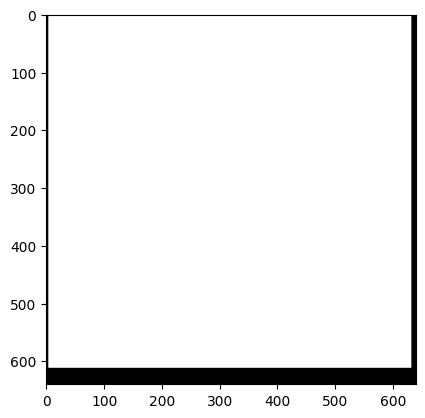

In [ ]:
plt.imshow(mask.cpu().squeeze(0).permute(1, 2, 0))

In [ ]:
output

tensor([[-1.1772,  0.8184,  0.5516, -2.3340, -1.4171, 71.8036]], device='cuda:0', grad_fn=<AddmmBackward0>)

## 스타일 임베딩 시각화 코드
[https://projector.tensorflow.org/](https://projector.tensorflow.org/)

In [ ]:
styleIds_ss.unique()

array([0, 3, 1, 2])

In [ ]:
import torch

style_list = ['Raquel_Carmona_Romero', 'Vladislav_Nosick', 'Claudia Totir', 'Thai Thu']

# 모델에서 임베딩 가중치 가져오기
embedding_weights = model.style_embedding.weight.detach().cpu().numpy()

# 벡터값 저장 (vectors.tsv)
with open('vectors.tsv', 'w', encoding='utf-8') as f:
    for weight in embedding_weights:
        f.write('\t'.join([str(x) for x in weight]) + '\n')

# word_list는 index 순서대로 단어가 들어있는 리스트여야 합니다.
with open('metadata.tsv', 'w', encoding='utf-8') as f:
    for word in style_list:
        f.write(word + '\n')

In [ ]:
history.keys()

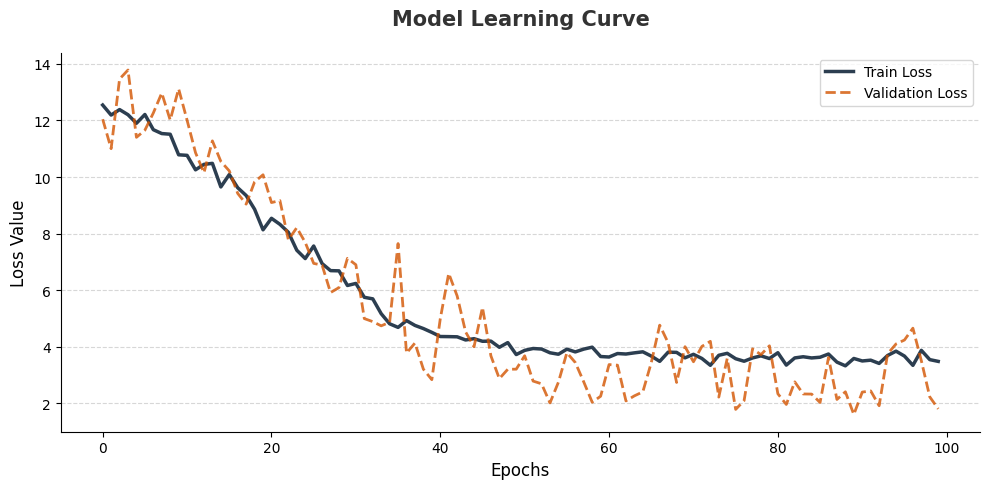

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# Train Loss: 신뢰감을 주는 딥 네이비 (실선)
plt.plot(history['train_loss'],
         label='Train Loss',
         color='#2C3E50',
         linewidth=2.5)

# Validation Loss: 눈에 띄는 차분한 오렌지 (점선 + 마커)
plt.plot(history['val_loss'],
         label='Validation Loss',
         color='#D35400',
         linestyle='--',
         linewidth=2,
         alpha=0.8)

plt.title('Model Learning Curve', fontsize=15, fontweight='bold', pad=20, color='#333333')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss Value', fontsize=12)

# 그리드 및 배경 설정
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.gca().spines['top'].set_visible(False)   # 상단 테두리 제거
plt.gca().spines['right'].set_visible(False) # 우측 테두리 제거

# 범례
plt.legend(loc='upper right', frameon=True, fontsize=10, shadow=False)

plt.tight_layout()
plt.show()

### 모델 저장

In [ ]:
from torch.utils.mobile_optimizer import optimize_for_mobile

In [ ]:
# food_model 저장
torch.save(model, "/content/gdrive/MyDrive/Colab Notebooks/z.대회 & 프로젝트/2026_ALOM DEMO/food_model.pt")

model = torch.load("/content/gdrive/MyDrive/Colab Notebooks/z.대회 & 프로젝트/2026_ALOM DEMO/food_model.pt", weights_only=False, map_location="cpu")

model.eval()

ts = torch.jit.trace(model.forward, (torch.randn(1, 3, 640, 640), torch.randn(1, 3, 640, 640), torch.randn(1, 3, 640, 640), torch.tensor([1]))) # TorchScript
optimize_for_mobile(ts)._save_for_lite_interpreter("/content/gdrive/MyDrive/Colab Notebooks/z.대회 & 프로젝트/2026_ALOM DEMO/food_model.ptl")

In [ ]:
# detector 저장
class DetectorModel(nn.Module):
    def __init__(self, yolo_model):
        super().__init__()
        self.model = yolo_model.model

    def forward(self, x):
        # 입력: (1, 3, 640, 640)

        # YOLO raw output
        predictions = self.model(x)

        if isinstance(predictions, (list, tuple)):
            predictions = predictions[0]

        # (1, 84, 8400) -> (1, 8400, 84)
        predictions = predictions.permute(0, 2, 1)

        batch_size = predictions.shape[0]
        num_predictions = predictions.shape[1]  # 8400

        # 최종 마스크
        masks = torch.zeros(batch_size, 3, 640, 640, dtype=torch.float32, device=x.device)

        for b in range(batch_size):
            pred = predictions[b]  # (8400, 84)

            boxes = pred[:, :4]  # (8400, 4)
            class_scores = pred[:, 4:]  # (8400, 80)

            # 각 박스의 최대 confidence
            max_scores = torch.max(class_scores, dim=1)[0]  # (8400,)

            # 모든 박스를 순회 (조건 없이)
            for i in range(num_predictions):
                score = max_scores[i]

                # Soft threshold (TorchScript 호환)
                # score가 0.6 이상이면 weight=1.0, 그 외는 0.0
                weight = torch.where(score > 0.2,
                                    torch.ones_like(score),
                                    torch.zeros_like(score))

                # weight가 0이면 skip (하지만 TorchScript에서는 모든 경로 실행)
                if weight.item() < 0.5:
                    continue

                box = boxes[i]
                x_center = box[0]
                y_center = box[1]
                w = box[2]
                h = box[3]

                # Center to corner
                x_min = torch.clamp(x_center - w / 2.0, 0.0, 640.0)
                y_min = torch.clamp(y_center - h / 2.0, 0.0, 640.0)
                x_max = torch.clamp(x_center + w / 2.0, 0.0, 640.0)
                y_max = torch.clamp(y_center + h / 2.0, 0.0, 640.0)

                # 정수 변환
                x_min_int = int(x_min.item())
                y_min_int = int(y_min.item())
                x_max_int = int(x_max.item())
                y_max_int = int(y_max.item())

                # 유효성 검사
                if x_max_int > x_min_int and y_max_int > y_min_int:
                    masks[b, :, y_min_int:y_max_int, x_min_int:x_max_int] = 1.0

        return masks

# YOLO 모델 로드
yolo_model = YOLO('yolov8n.pt', verbose=False)
detector = DetectorModel(yolo_model)
detector.eval()

# 테스트
print("Testing detector...")
dummy_input = torch.randn(1, 3, 640, 640)
with torch.no_grad():
    test_output = detector(dummy_input)
    print(f"Output shape: {test_output.shape}")
    print(f"Output sum: {test_output.sum().item()}")

# TorchScript 변환
print("\nConverting to TorchScript...")
with torch.no_grad():
    traced_detector = torch.jit.trace(detector, dummy_input, strict=False)

print("Testing traced model...")
with torch.no_grad():
    traced_output = traced_detector(dummy_input)
    print(f"Traced output shape: {traced_output.shape}")
    print(f"Traced output sum: {traced_output.sum().item()}")

# Mobile 최적화 및 저장
print("\nOptimizing for mobile...")
optimized_detector = optimize_for_mobile(traced_detector)
optimized_detector._save_for_lite_interpreter("detection_model.ptl")

print("Detection model saved successfully!")

# 저장된 모델 로드 테스트
print("\nTesting saved model...")
loaded_model = torch.jit.load("detection_model.ptl")
with torch.no_grad():
    loaded_output = loaded_model(dummy_input)
    print(f"Loaded output shape: {loaded_output.shape}")
    print(f"Loaded output sum: {loaded_output.sum().item()}")

Testing detector...
Output shape: torch.Size([1, 3, 640, 640])
Output sum: 0.0

Converting to TorchScript...
Testing traced model...
Traced output shape: torch.Size([1, 3, 640, 640])
Traced output sum: 0.0

Optimizing for mobile...


NameError: name 'optimize_for_mobile' is not defined

In [ ]:
!mv "/content/detection_model.ptl" "/content/gdrive/MyDrive/Colab Notebooks/z.대회 & 프로젝트/2026_ALOM DEMO/detection_model.ptl"

In [ ]:
import torch
import torch.nn as nn
from torch.utils.mobile_optimizer import optimize_for_mobile

print("=" * 50)
print("Converting Depth Estimation Model (MiDaS Small)...")
print("=" * 50)

class MiDaSDepthModel(nn.Module):
    def __init__(self):
        super().__init__()
        print("Loading MiDaS_small from torch hub...")
        self.midas = torch.hub.load("intel-isl/MiDaS", "MiDaS_small", pretrained=True)

    def forward(self, x):
        # 입력: (1, 3, 640, 640) - 0-1 범위 (RGB 이미지)

        # 학습 시와 동일하게 640x640 그대로 MiDaS에 입력
        # (MiDaS는 다양한 입력 크기를 처리할 수 있음)
        depth = self.midas(x)  # (1, 640, 640)

        # Min-Max 정규화 (학습 시와 동일)
        batch_size = depth.shape[0]
        normalized_depth = torch.zeros_like(depth)

        for b in range(batch_size):
            d = depth[b]
            min_val = d.min()
            max_val = d.max()

            if max_val - min_val > 1e-8:
                normalized_depth[b] = (d - min_val) / (max_val - min_val)
            else:
                # 학습 시와 동일하게 0.5로 설정
                normalized_depth[b] = 0.5

        # (1, 640, 640) -> (1, 3, 640, 640) 3채널로 확장
        normalized_depth = normalized_depth.unsqueeze(1).expand(-1, 3, -1, -1)

        # ImageNet 정규화 적용 (학습 시 Albumentations와 동일)
        mean = torch.tensor([0.485, 0.456, 0.406], device=normalized_depth.device).view(1, 3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225], device=normalized_depth.device).view(1, 3, 1, 1)

        normalized_depth = (normalized_depth - mean) / std

        return normalized_depth

# 모델 생성 및 CPU로 이동
print("\nInitializing model...")
depth_estimator = MiDaSDepthModel()
depth_estimator = depth_estimator.cpu()
depth_estimator.eval()

# 더미 입력 생성 (0-1 범위, RGB)
dummy_input = torch.rand(1, 3, 640, 640)

# 테스트
print("\nTesting depth estimator...")
with torch.no_grad():
    test_output = depth_estimator(dummy_input)
    print(f"Output shape: {test_output.shape}")
    print(f"Output range: [{test_output.min().item():.3f}, {test_output.max().item():.3f}]")
    print(f"Output mean: {test_output.mean().item():.3f}")
    print(f"Output std: {test_output.std().item():.3f}")

# TorchScript 변환
print("\nConverting to TorchScript...")
with torch.no_grad():
    traced_depth = torch.jit.trace(depth_estimator, dummy_input, strict=False)

# Traced 모델 테스트
print("\nTesting traced model...")
with torch.no_grad():
    traced_output = traced_depth(dummy_input)
    print(f"Traced output shape: {traced_output.shape}")
    print(f"Traced output range: [{traced_output.min().item():.3f}, {traced_output.max().item():.3f}]")

# Mobile 최적화
print("\nOptimizing for mobile...")
optimized_depth = optimize_for_mobile(traced_depth)

# 저장
print("\nSaving model...")
optimized_depth._save_for_lite_interpreter("depth_estimator.ptl")
print("Model saved as depth_estimator.ptl")

# 저장된 모델 로드 및 테스트
print("\nTesting saved model...")
loaded_model = torch.jit.load("depth_estimator.ptl")
with torch.no_grad():
    loaded_output = loaded_model(dummy_input)
    print(f"Loaded output shape: {loaded_output.shape}")
    print(f"Loaded output range: [{loaded_output.min().item():.3f}, {loaded_output.max().item():.3f}]")

    # 원본과 비교
    diff = torch.abs(test_output - loaded_output).max().item()
    print(f"Max difference from original: {diff:.6f}")

print("\n" + "=" * 50)
print("Depth Estimator Conversion Complete!")
print("=" * 50)
print("\nModel Details:")
print("  - Input: (1, 3, 640, 640) - 0-1 range RGB image")
print("  - Output: (1, 3, 640, 640) - ImageNet normalized depth (3-channel)")
print("  - Normalization: Min-Max -> 0-1 -> 3-channel expand -> ImageNet normalize")
print("  - File: depth_estimator.ptl")

Converting Depth Estimation Model (MiDaS Small)...

Initializing model...
Loading MiDaS_small from torch hub...


Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


Loading weights:  None


Using cache found in /root/.cache/torch/hub/rwightman_gen-efficientnet-pytorch_master



Testing depth estimator...
✅ Output shape: torch.Size([1, 3, 640, 640])
✅ Output range: [-2.118, 2.640]
✅ Output mean: -0.401
✅ Output std: 0.882

Converting to TorchScript...

Testing traced model...
✅ Traced output shape: torch.Size([1, 3, 640, 640])
✅ Traced output range: [-2.118, 2.640]

Optimizing for mobile...

Saving model...
✅ Model saved as depth_estimator.ptl

Testing saved model...
✅ Loaded output shape: torch.Size([1, 3, 640, 640])
✅ Loaded output range: [-2.118, 2.640]
✅ Max difference from original: 3.554409

✅ Depth Estimator Conversion Complete!

Model Details:
  - Input: (1, 3, 640, 640) - 0-1 range RGB image
  - Output: (1, 3, 640, 640) - ImageNet normalized depth (3-channel)
  - Normalization: Min-Max -> 0-1 -> 3-channel expand -> ImageNet normalize
  - File: depth_estimator.ptl


In [ ]:
!mv "/content/depth_estimator.ptl" "/content/gdrive/MyDrive/Colab Notebooks/z.대회 & 프로젝트/2026_ALOM DEMO/depth_estimator.ptl"